# Figure 3: Thematic Drift (Revised)

Based on original Cell 44 code. Changes from original:
- Lens (Hunt) / Lens (Pan) renamed to Lens-Hunt / Lens-Pan
- y-axis upper limit 0.15, ticks at 0.02 intervals up to 0.14
- Tones use circle markers, scholar lenses use triangle markers
- Times New Roman, DPI 500
- Output: Figure3_Drift_v3.png (does NOT overwrite originals)

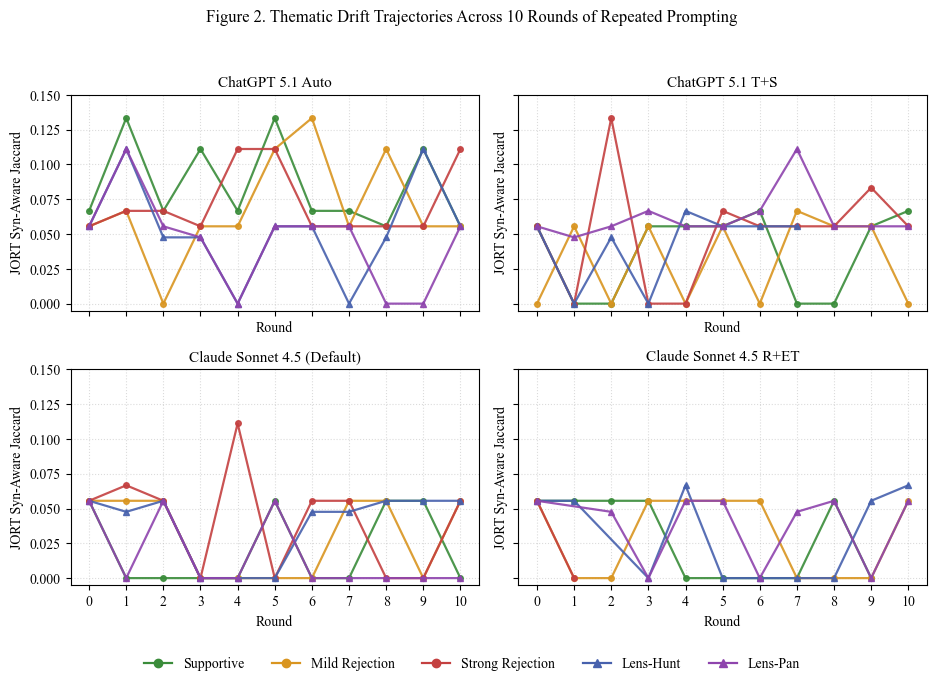

Saved: ..\8. Results\Figure3_Drift_v3.png  (1,093,062 bytes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman']

OUT = Path('../8. Results')
dr = pd.read_csv(OUT / 'drift_analysis.csv', skiprows=1)
dr = dr[dr['compliant'] == True].copy()

def _canon_tone(t):
    s = str(t).strip().lower()
    if 'support' in s:  return 'Supportive'
    if 'mild'    in s:  return 'Mild Rejection'
    if 'strong'  in s:  return 'Strong Rejection'
    if 'carter'  in s:  return 'Lens-Hunt'
    if 'bing'    in s:  return 'Lens-Pan'
    return t
dr['tone_c'] = dr['tone'].apply(_canon_tone)

models = ['ChatGPT 5.1 (Auto)',
          'ChatGPT 5.1 (Thinking + Study)',
          'Claude Sonnet 4.5',
          'Claude Sonnet 4.5 (Research + Extended Thinking)']
short_model = {
    'ChatGPT 5.1 (Auto)':                                'ChatGPT 5.1 Auto',
    'ChatGPT 5.1 (Thinking + Study)':                    'ChatGPT 5.1 T+S',
    'Claude Sonnet 4.5':                                 'Claude Sonnet 4.5 (Default)',
    'Claude Sonnet 4.5 (Research + Extended Thinking)':  'Claude Sonnet 4.5 R+ET',
}
tone_order  = ['Supportive', 'Mild Rejection', 'Strong Rejection',
               'Lens-Hunt', 'Lens-Pan']
tone_colors = {'Supportive':       '#3a8c3a',
               'Mild Rejection':   '#d99520',
               'Strong Rejection': '#c44040',
               'Lens-Hunt':        '#4761ad',
               'Lens-Pan':         '#8e44ad'}
tone_markers = {'Supportive':       'o',
                'Mild Rejection':   'o',
                'Strong Rejection': 'o',
                'Lens-Hunt':        '^',
                'Lens-Pan':         '^'}

fig, axes = plt.subplots(2, 2, figsize=(9.4, 6.6), sharex=True, sharey=True)
for ax, model in zip(axes.flat, models):
    sub = dr[dr['model'] == model]
    for tone in tone_order:
        s = sub[sub['tone_c'] == tone].groupby('round')['syn_jaccard_jort'].mean()
        if len(s):
            ax.plot(s.index, s.values, marker=tone_markers[tone], markersize=4, linewidth=1.6,
                    color=tone_colors[tone], label=tone, alpha=0.9)
    ax.set_title(short_model[model], fontsize=11)
    ax.set_xticks(range(0, 11))
    ax.set_ylim(-0.005, 0.15)
    ax.grid(True, linestyle=':', alpha=0.45)
    ax.set_axisbelow(True)
    ax.set_xlabel('Round')
    ax.set_ylabel('JORT Syn-Aware Jaccard')

handles = [plt.Line2D([0], [0], color=tone_colors[t], marker=tone_markers[t],
                      linewidth=1.6, label=t) for t in tone_order]
fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Figure 2. Thematic Drift Trajectories Across 10 Rounds of Repeated Prompting',
             fontsize=12, y=1.00)
fig.tight_layout(rect=[0, 0.04, 1, 0.97])

fig3_path = OUT / 'Figure3_Drift_v3.png'
fig.savefig(fig3_path, dpi=500, bbox_inches='tight')
plt.show()
print(f'Saved: {fig3_path}  ({fig3_path.stat().st_size:,} bytes)')